# SR5 · Feature Engineering: Turning Prices into Signals

Before any model can predict returns, someone has to decide what information to give it. This notebook builds a small set of features from prices and volume, puts them on a comparable scale, and measures how much each one predicts with the standard tool: the information coefficient.

## 1. Motivation

Feed raw prices into a machine-learning model and it will happily "learn" that Apple at &#36;300 is different from Apple at &#36;30, which tells you nothing about next month's return. Most of the work in quantitative signal research is not choosing a clever model. It is designing good **features**: transformations of raw data that are comparable across stocks and over time, and that might plausibly carry information about the future. The ML notebooks that follow (SR6, SR7) are only as good as the features built here.

## 2. Intuition

A good feature for cross-sectional stock prediction has three properties:

1. **It is comparable.** A 20-day return means the same thing for every stock and every year. A raw price, or a raw volume number, does not.
2. **It is stable over time** (statistically, **stationary**). Its distribution in 2012 looks like its distribution in 2024, so a pattern learned on one period can apply to another.
3. **It has an economic story.** Momentum (SR1), reversal (notebook 7), volatility and trading activity all have well-known stories. A feature with no story that happens to fit the past is most likely noise (notebook 6).

To measure whether a feature is useful, we ask a simple question each month: *do stocks that rank high on this feature tend to rank high on next month's return?* The correlation between those two rankings is the **information coefficient**.

## 3. The math

**Cross-sectional standardisation.** On each date $t$, convert a raw feature $x_{i,t}$ into a z-score across the $N$ stocks:
$$
\tilde x_{i,t} = \frac{x_{i,t} - \operatorname{mean}_j(x_{j,t})}{\operatorname{std}_j(x_{j,t})}.
$$
This removes anything that affects all stocks at once (e.g. a market-wide jump in volatility), so the feature only measures how a stock compares with the others *today*.

**Target.** The forward return over the next $h$ days, relative to the average stock:
$$
y_{i,t} = R_{i,\,t\to t+h} - \operatorname{mean}_j R_{j,\,t\to t+h}.
$$

**Information coefficient (IC).** On each date, the Spearman rank correlation between the feature and the target across stocks:
$$
\text{IC}_t = \operatorname{corr}\big(\operatorname{rank}(\tilde x_{\cdot,t}),\;\operatorname{rank}(y_{\cdot,t})\big).
$$
Using ranks makes the IC robust to outliers. A single month's IC is very noisy, so we look at its average over many months and at the **t-statistic** $\bar{\text{IC}} / (\operatorname{std}(\text{IC}_t)/\sqrt{T})$, where $T$ is the number of months.

To keep the months independent, we sample one date per month with $h = 21$ trading days, so the target windows don't overlap. Overlapping targets would make the t-statistic look far more significant than it is (SR6 deals with this in detail).

**What is a good IC?** Smaller than you might think. An average IC of 0.02–0.05 is considered useful in practice, if it is stable.

## 4. Code it

### 4.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
volume = pd.read_csv("../data/volume.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})
pd.set_option("display.width", 120)

stocks = meta.loc[meta.asset_type == "stock", "ticker"]
px, vol = prices[stocks], volume[stocks]
ret = px.pct_change()

### 4.2 Building the features

Each feature uses only data up to and including day $t$.

In [2]:
raw = {
    # Momentum (SR1): return from 12 months ago to 1 month ago
    "mom_12_1": px.shift(21) / px.shift(252) - 1,
    # Short-term reversal (notebook 7): last 5 days' return
    "rev_5d": px / px.shift(5) - 1,
    # Risk: realised volatility over the last 3 months
    "vol_63d": ret.rolling(63).std() * np.sqrt(252),
    # Trend: distance of the price from its 200-day average
    "dist_ma200": px / px.rolling(200).mean() - 1,
    # Attention: last week's dollar volume vs. its 3-month average (a "volume shock")
    "volume_shock": (px * vol).rolling(5).mean() / (px * vol).rolling(63).mean() - 1,
    # Size proxy: average daily dollar volume, in logs
    "log_dollar_vol": np.log((px * vol).rolling(63).mean()),
}

def cs_zscore(df):
    """Cross-sectional z-score: compare each stock with the others on the same day."""
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1), axis=0)

features = {name: cs_zscore(f) for name, f in raw.items()}
print("Example: Apple's raw 63-day volatility vs. its cross-sectional z-score")
print(pd.DataFrame({"raw vol_63d": raw["vol_63d"]["AAPL"], "z-score": features["vol_63d"]["AAPL"]})
      .loc[["2017-06-30", "2020-03-31", "2024-06-28"]].round(2))

Example: Apple's raw 63-day volatility vs. its cross-sectional z-score
            raw vol_63d  z-score
date                            
2017-06-30         0.18     0.33
2020-03-31         0.66     0.01
2024-06-28         0.27     0.57


In March 2020, Apple's raw volatility was 66%, more than three times its 2017 level. But *every* stock was volatile then, so its z-score was about 0: average for that day. In mid-2024 its raw volatility was a modest 27%, yet its z-score (0.57) was higher than in 2020, because other stocks were calmer still. The z-score answers the question a cross-sectional model needs: "how does this stock compare with the others *right now*?"

### 4.3 The target and the IC

In [3]:
h = 21
fwd = px.shift(-h) / px - 1                                   # R_{i, t -> t+h}  (uses the future: target only!)
target = fwd.sub(fwd.mean(axis=1), axis=0)                    # relative to the average stock

# One date per month, so the 21-day target windows don't overlap
dates = px.groupby(px.index.to_period("M")).tail(1).index
dates = dates[(dates >= "2011-01-01") & (dates <= target.dropna(how="all").index[-1])]

def ic_series(feature, target, dates):
    """Spearman rank correlation across stocks on each date."""
    out = {}
    for d in dates:
        x, y = feature.loc[d], target.loc[d]
        ok = x.notna() & y.notna()
        out[d] = x[ok].rank().corr(y[ok].rank())          # Pearson on ranks = Spearman
    return pd.Series(out)

ics = pd.DataFrame({name: ic_series(f, target, dates) for name, f in features.items()})
T = len(ics)
ic_table = pd.DataFrame({
    "mean IC": ics.mean(),
    "std IC": ics.std(),
    "t-stat": ics.mean() / (ics.std() / np.sqrt(T)),
    "% months > 0": (ics > 0).mean(),
}).sort_values("t-stat")
print(f"{T} monthly observations")
ic_table.round(3)

188 monthly observations


,mean IC,std IC,t-stat,% months > 0
volume_shock,-0.019,0.172,-1.512,0.415
rev_5d,-0.007,0.228,-0.423,0.500
mom_12_1,0.015,0.267,0.757,0.521
log_dollar_vol,0.020,0.248,1.092,0.559
dist_ma200,0.021,0.264,1.102,0.532
vol_63d,0.037,0.310,1.646,0.574


None of the six features clears the $|t| > 2$ bar on this universe:

- **vol_63d** has the highest mean IC (0.037, t ≈ 1.6). More volatile stocks did slightly *better* here. In broad academic samples the opposite is usually found (the "low-volatility anomaly"). In a survivor universe dominated by a tech-led bull market, volatile winners such as NVIDIA are exactly the ones that ended up in the sample.
- **mom_12_1** and **dist_ma200** are slightly positive, consistent with SR1's weak momentum result.
- **rev_5d** is close to zero on average. Its sign is negative in the long run, as expected for reversal (recent losers do a bit better), but very weakly.
- **volume_shock** is weakly negative: stocks with a sudden burst of trading tended to lag slightly the following month.

Notice that the standard deviation of the monthly IC (0.2–0.3) is about ten times its mean. In any given month, a feature's ranking is mostly noise. Only averages over many months reveal an edge.

### 4.4 Is the IC stable over time?

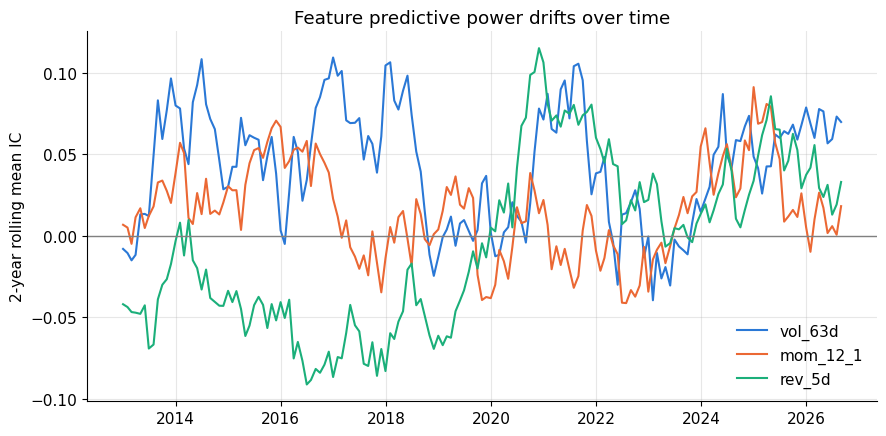

In [4]:
rolling_ic = ics.rolling(24).mean()     # 2-year rolling average IC
fig, ax = plt.subplots()
for name, c in [("vol_63d", COLORS[0]), ("mom_12_1", COLORS[1]), ("rev_5d", COLORS[2])]:
    ax.plot(rolling_ic.index, rolling_ic[name], label=name, color=c)
ax.axhline(0, color="grey", linewidth=1)
ax.set_ylabel("2-year rolling mean IC")
ax.set_title("Feature predictive power drifts over time")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The rolling ICs move a lot. Reversal had a clearly negative IC (it worked as a reversal signal) from 2014 to 2019, then flipped positive in 2020–2021, when recent winners kept winning. Volatility's IC swings between −0.03 and +0.10. A feature that looks good over a full sample can spend years not working. This is one reason professional signal researchers combine many weak features rather than relying on any one.

### 4.5 Are the features telling us different things?

In [5]:
# Average cross-sectional correlation between features, over the monthly dates
corr = sum(pd.DataFrame({n: f.loc[d] for n, f in features.items()}).corr() for d in dates) / len(dates)
corr.round(2)

,mom_12_1,rev_5d,vol_63d,dist_ma200,volume_shock,log_dollar_vol
mom_12_1,1.00,0.05,0.15,0.66,0.05,0.22
rev_5d,0.05,1.00,0.00,0.26,0.07,-0.00
vol_63d,0.15,0.00,1.00,0.07,-0.01,0.32
dist_ma200,0.66,0.26,0.07,1.00,0.12,0.13
volume_shock,0.05,0.07,-0.01,0.12,1.00,-0.00
log_dollar_vol,0.22,-0.00,0.32,0.13,-0.00,1.00


Most features are close to uncorrelated, so each brings mostly new information. The exception is **mom_12_1 and dist_ma200 (0.66)**: both measure "has this stock been going up?", over slightly different windows. Including both in a model mostly double-counts one idea. Volatility is mildly correlated with dollar volume (0.32): volatile stocks tend to attract more trading.

## 5. Takeaways and where it breaks

- **Features should be comparable and stable.** Cross-sectional z-scores (or ranks) are the simplest way to get there.
- **The IC is the standard first test of a feature.** Report its mean, its t-statistic, and how it varies over time, not a single number.
- **Small ICs are normal.** Even professional signals rarely average above 0.05. A feature with an IC of 0.2 on stock returns is almost always a bug, usually look-ahead.
- **Where it breaks:** with 43 stocks, each monthly IC is computed from very few points, so it is noisy. About 190 months is still a short history for a t-statistic. And the more features you try, the more likely one looks good by chance (notebook 6).
- **Redundancy matters.** Highly correlated features add little new information and can confuse models.

**What you could build:** a shared feature store for the club: a library that computes a standard set of point-in-time features for any universe, with an IC report for each. The Sentiment & Alt Data team's signals can be added and tested the same way.